In [2]:
%load_ext autoreload
import torch
import pandas as pd
import numpy as np
import os
import l4casadi as l4c
import casadi as cas
import matplotlib.pyplot as plt
import seaborn as sns
import control as ctrl
from models import *
import utils.utilities as utilities
torch.backends.mkldnn.flags.rnn = False
torch.backends.mkldnn.enabled = False
from scipy.linalg import block_diag
c1_picker  = np.loadtxt('data/core_regions/c1_picker.txt')
c2_picker  = np.loadtxt('data/core_regions/c2_picker.txt')
sus_picker = np.loadtxt('data/core_regions/sus_picker.txt')
from forecaster_config_tester import make_sym


Picking set point

In [2]:
Z_target = 2500*torch.ones((c1_picker.shape[-1],1))
Z_target[np.where(c1_picker == 1)[-1]] = 3000
Z_tilde = np.loadtxt('data/mpc_files/Z_tilde.txt')

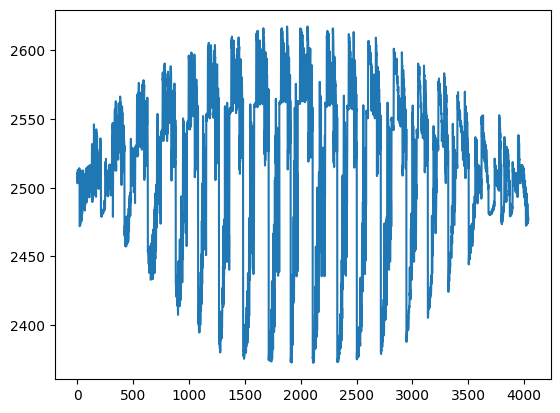

In [3]:
plt.plot(Z_tilde)

In [4]:
%autoreload 2
j=3
folder = 'forecaster_configs/'
u_dim, out_dim = 4, 64
seq_len = 10
forecaster = SHREDForecaster(
    u_dim=u_dim+out_dim, 
    out_dim=out_dim, 
    lstm_params = {
                'seq_len': seq_len, 
                'n_layers': 1,
                'hidden_dim': 64,
                },
    batch_first=True,
    data_manager=None,
)
forecaster_weights = torch.load(folder+f'config{j}.json')
forecaster.load_state_dict(forecaster_weights)
input_shape = (10,70)
input_shape = (input_shape[0]*input_shape[1],1)
output_shape = (64,1)
sym_model,forecaster,dforecaster = make_sym(None, f'_l4c_config{j}_', input_shape, output_shape, f'forecaster_config{j}', wrapper=None,jacjac=False,folder=folder)

FOUND EXISTING l4casadi build. Loading...
Defining the casadi function
In shape :  (700, 1)
Out shape:  (64, 1)


In [133]:
class closed_loop_wrapper(nn.Module):
    def __init__(self, forecaster, controller, x_tilde, u_tilde):
        super(closed_loop_wrapper, self).__init__()
        self.forecaster = forecaster
        self.controller = torch.tensor(controller,dtype=torch.float32)
        self.x_tilde = torch.tensor(x_tilde,dtype=torch.float32).reshape(1,-1)
        self.u_tilde = torch.tensor(u_tilde,dtype=torch.float32).reshape(1,-1)
    def forward(self, x):
        print(x.shape)
        print(self.controller.shape)
        u = (x - self.x_tilde) @ self.controller.T + self.u_tilde
        print(u.shape)
        ux = torch.cat([u,x],dim=1).reshape(-1,1)
        print(ux.shape)
        return self.forecaster(ux)

In [3]:
# from lin_error_bounds import *
from models import SHREDForecaster, UnivForecasterWrapper
j=3
forecaster_folder = 'forecaster_configs/'
u_picker = np.loadtxt(forecaster_folder+f'u_picker{j}.txt')
u_dim, out_dim = 4, 64
seq_len = 10
forecaster = SHREDForecaster(
    u_dim=u_dim+out_dim, 
    out_dim=out_dim, 
    lstm_params = {
                'seq_len': seq_len, 
                'n_layers': 1,
                'hidden_dim': 64,
                },
    batch_first=True,
    data_manager=None,
)
forecaster_weights = torch.load(forecaster_folder+f'config{j}.json')
forecaster.load_state_dict(forecaster_weights)
forecaster = UnivForecasterWrapper(forecaster, u_picker)

mpc_folder = 'mpc_configs/'
u_tilde_prev = np.loadtxt(mpc_folder+'/u_tilde_prev.txt')
x_tilde_prev = np.loadtxt(mpc_folder+'x_tilde_prev.txt')
Kf = np.loadtxt(mpc_folder+'Kmatrix.txt')
Ak = np.loadtxt(mpc_folder+'AKmatrix.txt')
closed_loop = closed_loop_wrapper(forecaster, Kf, x_tilde=x_tilde_prev[-1], u_tilde=u_tilde_prev[-1])


build_dir = f'_l4c_closedloop{j}_'
input_shape = (10,70)
input_shape = (input_shape[0]*input_shape[1],1)
output_shape = (64,1)
sym_model,forecaster,dforecaster = make_sym(None, f'_l4c_config{j}_', input_shape, output_shape, f'forecaster_config{j}', wrapper=None,jacjac=False,folder=forecaster_folder)

NameError: name 'closed_loop_wrapper' is not defined

In [135]:
closed_loop(torch.zeros((1,64)))

torch.Size([1, 64])
torch.Size([6, 64])
torch.Size([1, 6])
torch.Size([70, 1])
torch.Size([10, 0]) (6, 4)


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 6 is different from 0)

In [6]:
folder = 'mpc_configs/'
u_tilde_prev = np.loadtxt(folder+'/u_tilde_prev.txt')
x_tilde_prev = np.loadtxt(folder+'x_tilde_prev.txt')
u_tilde_prev.shape, x_tilde_prev.shape
seq_len, u_dim = u_tilde_prev.shape
x_dim = x_tilde_prev.shape[1]

In [7]:
u_dim = 6

In [8]:
seq_len = 10
def B_func(X): # Dependence on last input, not full seq
    return np.array(dforecaster(X)[:,u_dim*(seq_len-1):u_dim*(seq_len)])

def A_func(X): #Dependence on last state, not full seq
    return np.array(dforecaster(X)[:,u_dim*(seq_len)+x_dim*(seq_len-1):])

X_prev = np.vstack([u_tilde_prev.reshape(-1,1), x_tilde_prev.reshape(-1,1)])
X_prev.shape

(700, 1)

In [9]:
A = A_func(X_prev)
B = B_func(X_prev)
print(A.shape, B.shape)

(64, 64) (64, 6)


In [10]:
# PBH test — check each eigenvalue
n = A.shape[0]
eigenvalues = np.linalg.eigvals(A)
all_ctrb = True
for lam in eigenvalues:
    PBH = np.hstack([-A + lam * np.eye(n), B])
    r = np.linalg.matrix_rank(PBH)
    
    c = r == n
    if not c:
        print(f"λ = {lam:.2f} → {'Controllable' if c else 'UNCONTROLLABLE'}")
        all_ctrb = False
if all_ctrb:
    print('All modes are controllable, so the system is controllable.')


All modes are controllable, so the system is controllable.


In [11]:
if (np.abs(eigenvalues) < 1).all():
    print('The system is stable')

The system is stable


Computing the LQR controller

In [12]:
Q = np.diag(np.ones(x_dim))
R = np.diag(0.01*np.ones(6))
K_f, S, eigs = ctrl.dlqr(A,B,Q,R)
Ak = A - B@K_f
Qk = Q + K_f.T @ R @ K_f
np.savetxt(folder+'Kmatrix.txt', K_f)
np.savetxt(folder+'AKmatrix.txt', Ak)
np.savetxt(folder+'QKmatrix.txt', Qk)

In [14]:
np.linalg.eigvals(Qk)

array([1.0980301 , 1.00854413, 1.00517584, 1.00137401, 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        ])

In [22]:
from scipy.linalg import solve_discrete_lyapunov
P = solve_discrete_lyapunov(Ak, Qk)
print('The terminal cost is V_f(x) = x^TPx')
# print(np.linalg.eig(P).eigenvalues.max())

The terminal cost is V_f(x) = x^TPx


In [26]:
np.savetxt(folder+'Pmatrix.txt', P)

In [69]:
np.linalg.eigvals(S), np.linalg.eigvals(P)

(array([1.42978323, 1.16640123, 1.1259346 , 1.09975321, 1.05671384,
        1.02252695, 1.00766307, 1.00268597, 1.00167627, 1.00071579,
        1.00044385, 1.00021125, 1.00018686, 1.00013096, 1.00006411,
        1.00004755, 1.00004108, 1.00001435, 1.00001364, 1.00001078,
        1.00000882, 1.00000577, 1.00000498, 1.00000344, 1.00000213,
        1.00000178, 1.00000146, 1.00000121, 1.00000094, 1.00000069,
        1.00000064, 1.00000053, 1.00000043, 1.00000034, 1.00000026,
        1.00000024, 1.00000021, 1.00000018, 1.00000014, 1.00000013,
        1.0000001 , 1.00000008, 1.00000005, 1.00000004, 1.00000004,
        1.00000003, 1.00000002, 1.00000002, 1.00000001, 1.00000001,
        1.00000001, 1.00000001, 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        ]),
 array([1.40260596, 1.17456056, 1.12900636, 1.10066664, 1.05815316,
        1.0270899 , 1.02010467, 1.00719783, 1.00294154, 1.

In [74]:
print(np.linalg.eigvals(P).max())
sigAkmax = np.linalg.svdvals(Ak).max()
lamQkmax = np.linalg.eigvals(Qk).max()
lamQkmin = np.linalg.eigvals(Qk).min()
LamP = lamQkmax/(1 - sigAkmax**2)
print(LamP)


1.4026059642607112
1.5897314563802152


In [138]:
lamm = 1622.1239
# lamm = 1
n_x = 64 #CCHECK
c_hess = lamm*np.sqrt(n_x)/2

/tmp/ipykernel_27634/2110640091.py:6: RuntimeWarning: invalid value encountered in sqrt
  alpha_func = lambda d: (-b + np.sqrt(b**2 - 4*a*(d*lamQkmax - lamQkmin)))/(2*a)


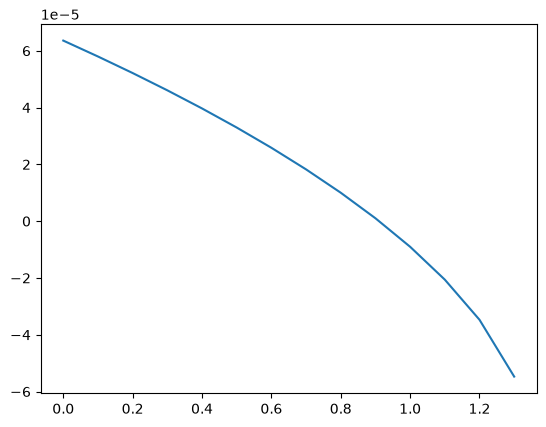

In [139]:
delta = 0.1
a = (c_hess**2)*LamP
b = 2*c_hess*sigAkmax*LamP
c = delta*lamQkmax - lamQkmin
alpha = (-b + np.sqrt(b**2 - 4*a*c))/(2*a)
alpha_func = lambda d: (-b + np.sqrt(b**2 - 4*a*(d*lamQkmax - lamQkmin)))/(2*a)
delta_range = np.arange(0,10,0.1)
plt.plot(delta_range,alpha_func(delta_range))

In [ ]:
matrix_folder = 'data/mpc_files/'
np.savetxt(matrix_folder+'Qkmatrix.txt', Qk)
np.savetxt(matrix_folder+'Pmatrix.txt', P)
